# GoEmotions — Multi-Label Emotion Classification

Fine-tunes an **encoder-only transformer backbone** on the GoEmotions dataset for **27-class multi-label emotion prediction** with Neutral fallback.

| Concept | Detail |
|---|---|
| Task | Multi-label classification (One-vs-Rest style) |
| Classes | 27 emotions; Neutral inferred when no emotion ≥ threshold |
| Loss | Asymmetric Loss (default) — handles pos/neg imbalance separately |
| Imbalance | `WeightedRandomSampler` + `AsymmetricLoss` |
| Scheduler | Cosine with linear warmup |

### Available backbones

| Key | Architecture | Params | Notes |
|---|---|---|---|
| `bert` | BERT-base-uncased | 110M | Classic baseline |
| `roberta` | RoBERTa-base | 125M | Stronger than BERT, no NSP |
| `deberta` | DeBERTa-v3-base | 184M | Best single-model on GLUE |
| `electra` | ELECTRA-base-discriminator | 110M | Fast, replaced-token detection |

## 0 · Setup

In [1]:
import os, sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: D:\USTH\nlp\final_prj


## 1 · Configure hyperparameters

Edit keys below or modify `config/config.yaml` directly.

In [ ]:
import yaml

CONFIG_PATH = 'config/config.yaml'

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

# ── Data ──────────────────────────────────────────────────────────────────
# ── Model ──────────────────────────────────────────────────────────────────
# Choose backbone: bert | roberta | deberta | electra
cfg['model']['name']                    = 'electra'
cfg['model']['dropout']                 = 0.1

# ── Training ───────────────────────────────────────────────────────────────
cfg['training']['epochs']               = 10
cfg['training']['batch_size']           = 8
cfg['training']['lr']                   = 2e-5
cfg['training']['optimizer']            = 'adamw'
cfg['training']['scheduler']            = 'cosine_warmup'
cfg['training']['warmup_ratio']         = 0.1
cfg['training']['early_stopping_patience'] = 3

# ── Loss ───────────────────────────────────────────────────────────────────
# Options: bce | bce_weighted | focal_bce | asymmetric
cfg['training']['loss']                 = 'asymmetric'
cfg['training']['asl_gamma_pos']        = 0.0
cfg['training']['asl_gamma_neg']        = 4.0
cfg['training']['asl_clip']             = 0.05

# ── Threshold ──────────────────────────────────────────────────────────────
cfg['training']['threshold']            = 0.5

with open(CONFIG_PATH, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)

print('Config saved:')
print(f"  model      : {cfg['model']['name']}")
print(f"  epochs     : {cfg['training']['epochs']}")
print(f"  batch_size : {cfg['training']['batch_size']}")
print(f"  lr         : {cfg['training']['lr']}")
print(f"  loss       : {cfg['training']['loss']}")
print(f"  threshold  : {cfg['training']['threshold']}")

Config saved:
  model      : electra
  epochs     : 10
  batch_size : 32
  lr         : 2e-05
  loss       : asymmetric
  threshold  : 0.5


## 2 · Inspect dataset label distribution

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\admin\.cache\huggingface\hub\models--google--electra-base-discriminator. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[DataLoader] Loading individual .arrow files from 'data/'
  train : go_emotions-train.arrow
  val   : go_emotions-validation.arrow
  test  : go_emotions-test.arrow
[DataLoader] Train: 43410 | Val: 5426 | Test: 5427
[DataLoader] Max token length : 128
[DataLoader] Label counts (train) : {'admiration': 4130, 'amusement': 2328, 'anger': 1567, 'annoyance': 2470, 'approval': 2939, 'caring': 1087, 'confusion': 1368, 'curiosity': 2191, 'desire': 641, 'disappointment': 1269, 'disapproval': 2022, 'disgust': 793, 'embarrassment': 303, 'excitement': 853, 'fear': 596, 'gratitude': 2662, 'grief': 77, 'joy': 1452, 'love': 2086, 'nervousness': 164, 'optimism': 1581, 'pride': 111, 'realization': 1110, 'relief': 153, 'remorse': 545, 'sadness': 1326, 'surprise': 1060}


C:\Users\admin\AppData\Local\Temp\ipykernel_23536\3095388555.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([names[i] for i in order], rotation=45, ha='right', fontsize=8)


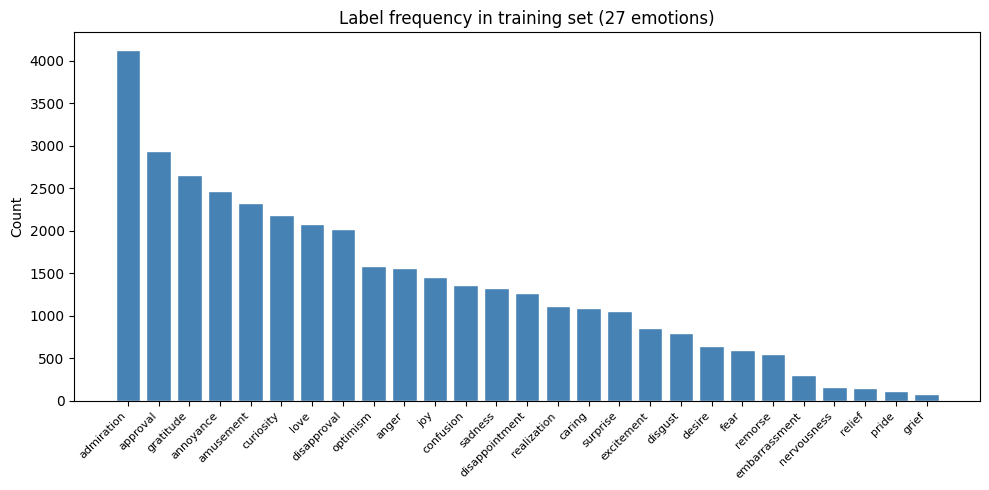

In [3]:
from src.dataloader import get_dataloaders, EMOTION_NAMES
import matplotlib.pyplot as plt
import numpy as np

train_loader, val_loader, test_loader, info = get_dataloaders(cfg)

counts = info['label_counts']
names  = list(counts.keys())
vals   = list(counts.values())
order  = np.argsort(vals)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([names[i] for i in order], [vals[i] for i in order], color='steelblue', edgecolor='white')
ax.set_xticklabels([names[i] for i in order], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Count')
ax.set_title('Label frequency in training set (27 emotions)')
fig.tight_layout()
plt.show()

## 3 · Train

In [4]:
from src.train import train

result = train(config_path=CONFIG_PATH)

print('\nTraining complete.')
print(f"  Best val_loss  : {result['best_val_loss']:.4f}")
print(f"  Best micro_f1  : {result['best_val_micro_f1']:.4f}")
print(f"  Best epoch     : {result['best_epoch']}")
print(f"  Log saved to   : {result['log_path']}")

[train] Device: cpu | AMP: False
[DataLoader] Loading individual .arrow files from 'data/'
  train : go_emotions-train.arrow
  val   : go_emotions-validation.arrow
  test  : go_emotions-test.arrow
[DataLoader] Train: 43410 | Val: 5426 | Test: 5427
[DataLoader] Max token length : 128
[DataLoader] Label counts (train) : {'admiration': 4130, 'amusement': 2328, 'anger': 1567, 'annoyance': 2470, 'approval': 2939, 'caring': 1087, 'confusion': 1368, 'curiosity': 2191, 'desire': 641, 'disappointment': 1269, 'disapproval': 2022, 'disgust': 793, 'embarrassment': 303, 'excitement': 853, 'fear': 596, 'gratitude': 2662, 'grief': 77, 'joy': 1452, 'love': 2086, 'nervousness': 164, 'optimism': 1581, 'pride': 111, 'realization': 1110, 'relief': 153, 'remorse': 545, 'sadness': 1326, 'surprise': 1060}


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraModel LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
electra.embeddings_project.bias                   | UNEXPECTED |  | 
electra.embeddings_project.weight                 | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[train] Model: electra | Trainable params: 108,912,411


Epoch 1/10 [train]:   0%|          | 0/1357 [00:00<?, ?batch/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

D:\USTH\nlp\final_prj\src\train.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(scaler is not None)):
Epoch 1/10 [train]:   0%|          | 1/1357 [00:56<21:26:55, 56.94s/batch, loss=0.0566]

: 

## 4 · Plot training curves

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

log_df = pd.read_csv(result['log_path'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(log_df['epoch'], log_df['train_loss'], label='Train loss')
axes[0].plot(log_df['epoch'], log_df['val_loss'],   label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

# F1
axes[1].plot(log_df['epoch'], log_df['val_micro_f1'],    label='Micro F1')
axes[1].plot(log_df['epoch'], log_df['val_macro_f1'],    label='Macro F1')
axes[1].plot(log_df['epoch'], log_df['val_weighted_f1'], label='Weighted F1')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].set_title('Validation F1'); axes[1].legend(); axes[1].grid(True)

fig.suptitle(f"Training curves — {cfg['model']['name']}", fontsize=13)
fig.tight_layout()
plt.show()

## 5 · Threshold search on validation set

Sweep thresholds to find the one that maximises val micro-F1.

In [ ]:
import torch
import numpy as np
from sklearn.metrics import f1_score
from src.train import build_model
from src.utils import apply_threshold
from tqdm.notebook import tqdm as tqdm_nb

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt      = torch.load(result['checkpoint_path'], map_location=device)
model_val = build_model(cfg).to(device)
model_val.load_state_dict(ckpt['model_state'])
model_val.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        logits = model_val(
            batch['input_ids'].to(device),
            batch['attention_mask'].to(device),
        )
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(batch['labels'].numpy())

all_probs  = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

thresholds  = np.arange(0.2, 0.8, 0.02)
micro_f1s   = []
for t in thresholds:
    preds = apply_threshold(all_probs, t)
    micro_f1s.append(f1_score(all_labels, preds, average='micro', zero_division=0))

best_t  = thresholds[np.argmax(micro_f1s)]
best_f1 = max(micro_f1s)
print(f'Best threshold: {best_t:.2f}  ->  micro F1 = {best_f1:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(thresholds, micro_f1s)
plt.axvline(best_t, color='red', linestyle='--', label=f'Best={best_t:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Micro F1')
plt.title('Threshold Search (Validation set)')
plt.legend(); plt.grid(True)
plt.show()

# Update config with best threshold
cfg['training']['threshold'] = float(round(best_t, 2))
with open(CONFIG_PATH, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)
print(f'Config updated: threshold = {cfg["training"]["threshold"]}')

## 6 · Evaluate on test set

In [ ]:
from src.test import evaluate

metrics = evaluate(config_path=CONFIG_PATH)

## 7 · Display per-class F1 & prediction heatmap

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

img_f1 = Image.open(metrics['f1_chart_path'])
axes[0].imshow(img_f1); axes[0].axis('off'); axes[0].set_title('Per-Class F1')

img_hm = Image.open(metrics['heatmap_path'])
axes[1].imshow(img_hm); axes[1].axis('off'); axes[1].set_title('Prediction Heatmap')

fig.tight_layout()
plt.show()

print(f"Micro F1       : {metrics['micro_f1']:.4f}")
print(f"Macro F1       : {metrics['macro_f1']:.4f}")
print(f"Hamming Loss   : {metrics['hamming']:.4f}")
print(f"Subset Accuracy: {metrics['subset_accuracy']:.4f}")
print(f"Neutral Acc    : {metrics['neutral_accuracy']:.4f}")